In [ ]:
import scanpy as sc
import pickle as pickle
import pandas as pd
import numpy as np
from os.path import exists
import matplotlib.pyplot as plt
import random
import os
import re
import matplotlib as mpl
import ast
import seaborn as sns
from matplotlib.patches import Rectangle, PathPatch
from matplotlib.lines import Line2D
from matplotlib.cbook import boxplot_stats


mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [ ]:
def compute_transition_scores(data, clusters, chosen_transitions, percentile = 0.9):
    '''Calculates a score indicating the probability that two clusters are a cell state transition.
    The score says what percentage of posterior samples in the second cluster are larger than the 
    95th percentile of the first cluster. Scores below 0.5 indicate uncertain transitions.
    
    Parameters
    ----------
    mod
        Trained model with posterior samples.
    cluster
        Cluster identity of cells in the data.
    chosen_transitions
        List with pairs of clusters to calculate transition scores for.
    percentile
        Percentile threshold to use in score calculation. Default is 0.95.

    Returns
    -------
    Dataframe with scores for each transition'''
    
    T_c = data['T_c']
    tab = pd.DataFrame(columns = ('Transition', 'Score'), index = list(range(len(chosen_transitions))))
    categories = clusters
    for i in range(len(chosen_transitions)):
        tab.loc[i, 'Transition'] = chosen_transitions[i]
        if np.sum(categories == chosen_transitions[i][0]) > 0:
            tab.loc[i, 'Score'] = np.sum(np.quantile(T_c[categories == chosen_transitions[i][0]], percentile) < T_c[categories == chosen_transitions[i][1]])/np.sum(categories == chosen_transitions[i][1])
    return tab

In [ ]:
data_dir = '../data/GBM/'
clone_dir = '../data/GBM/clones/'
save_dir = '../data/cell2fate/'
outdir = '../data/trajectories/plots/'

patients = np.array(('at12', 'at14', 'at4', 'at6', 'at9', 'at11', 
                     'at13', 'at15', 'at5', 'at7', 'at10', 'at3'))
good_clones = ['at4_0',
 'at10_1',
 'at15_3',
 'at4_2',
 'at6_0',
 'at4_1',
 'at10_2',
 'at9_2',
 'at15_4',
 'at15_0',
 'at15_6',
 'at15_2',
 'at10_0',
 'at5_9',
 'at5_4',
 'at5_2',
 'at9_4',
 'at9_0',
 'at3_3',
 'at13_0',
 'at6_4',
 'at7_0',
 'at6_5']

In [ ]:
# recompute transition scores with new cycling annotation
prolif_anno = pd.read_csv('../data/proliferative/proliferative_annotation_granular.csv', index_col=0)

prolif_annotation = {
    'Proliferative 0':'Cycling AC',
    'Proliferative 1':'Cycling Neuron-like',
    'Proliferative 2':'Cycling NPC-OPC',
    'Proliferative 3':'Cycling NPC-OPC',
    'Proliferative 4':'Cycling AC',
    'Proliferative 5':'Cycling AC'
}

prolif_anno['prolif_annotation'] = prolif_anno['annotation_granular_prolif'].map(prolif_annotation)
prolif_anno['annotation_granular'] = np.where(
    ~prolif_anno['prolif_annotation'].isnull(), prolif_anno['prolif_annotation'],
    prolif_anno['annotation_granular_prolif'])
prolif_anno = prolif_anno.drop(['prolif_annotation'], axis=1)

prolif_anno = prolif_anno.set_index('cell_id')

In [ ]:
malignant_cts = [
 'Cycling AC',
 'Cycling Neuron-like',
 'Cycling NPC-OPC',
 'AC progenitor-like 1',
 'AC progenitor-like 2',
 'Proliferative AC-OPC-like',
 'AC progenitor-like 3',
 'AC-gliosis-like 1',
 'AC-gliosis-like 2',
 'AC-gliosis-like 3',
 'AC-gliosis-like 4',
 'AC progenitor-like 4',
 'Gliosis-like',
 'Proliferative nIPC-like',
 'Hypoxic 1',
 'Hypoxic 2',
 'Proliferative NPC-OPC-like',
 'OPC-NPC-like 1',
 'OPC-NPC-like 2',
 'OPC-NPC-like 3',
 'NPC-neuronal-like 1',
 'NPC-neuronal-like 2',
 'NPC-neuronal-like 3',
 'NPC-neuronal-like 4',
 'NPC-neuronal-like 5',
 'OPC-neuronal-like',
 'OPC-like 1',
 'OPC-like 2',
 'OPC-like 3',
 'OPC-like 4',
 'OPC-like 5',]

In [ ]:
from itertools import combinations
from itertools import permutations

ct_list = malignant_cts
chosen_transitions = list(set(permutations(ct_list, 2)))

# Compute transition scores (granular)

In [ ]:
all_scores = pd.DataFrame(columns = chosen_transitions + ['Average'])

path = save_dir
time_tab_list = []
seed = 0
for i in range(len(patients)):
    patient = patients[i]
    print(patient)
    clones = pd.read_csv(clone_dir + patient + '_2.h5ad')
    unique_clones = np.unique(clones['predicted'])
    for j in range(len(unique_clones)):
        print(j)
        filename = save_dir + patient + 'clone' + str(unique_clones[j]) + '_2_new2.pickle'
        with open(filename, 'rb') as handle:
            data = pickle.load(handle)

        # set new label data
        label_data = data['TME_GBM_granular']
        label_data.index.name = "cell_id"
        label_data.name = "TME_GBM_granular"
        
        label_data = pd.DataFrame(label_data).reset_index().merge(
            prolif_anno[['annotation_granular']].reset_index(), on = 'cell_id' 
        ).set_index('cell_id')
        label_data = label_data['annotation_granular']
        label_data = label_data.reindex(data['TME_GBM_granular'].index)

        scores = compute_transition_scores(data, label_data, chosen_transitions, percentile = 0.9)
        all_scores.loc[patient + '_' + str(j),:] = np.array(list(scores['Score']) + [np.mean(scores['Score'])])

at12
0


/tmp/ipykernel_2317419/3146797117.py:27: RuntimeWarning: invalid value encountered in long_scalars
  tab.loc[i, 'Score'] = np.sum(np.quantile(T_c[categories == chosen_transitions[i][0]], percentile) < T_c[categories == chosen_transitions[i][1]])/np.sum(categories == chosen_transitions[i][1])


1


/tmp/ipykernel_2317419/3146797117.py:27: RuntimeWarning: invalid value encountered in long_scalars
  tab.loc[i, 'Score'] = np.sum(np.quantile(T_c[categories == chosen_transitions[i][0]], percentile) < T_c[categories == chosen_transitions[i][1]])/np.sum(categories == chosen_transitions[i][1])


2


...

/tmp/ipykernel_2317419/3146797117.py:27: RuntimeWarning: invalid value encountered in long_scalars
  tab.loc[i, 'Score'] = np.sum(np.quantile(T_c[categories == chosen_transitions[i][0]], percentile) < T_c[categories == chosen_transitions[i][1]])/np.sum(categories == chosen_transitions[i][1])


4


/tmp/ipykernel_2317419/3146797117.py:27: RuntimeWarning: invalid value encountered in long_scalars
  tab.loc[i, 'Score'] = np.sum(np.quantile(T_c[categories == chosen_transitions[i][0]], percentile) < T_c[categories == chosen_transitions[i][1]])/np.sum(categories == chosen_transitions[i][1])


5


/tmp/ipykernel_2317419/3146797117.py:27: RuntimeWarning: invalid value encountered in long_scalars
  tab.loc[i, 'Score'] = np.sum(np.quantile(T_c[categories == chosen_transitions[i][0]], percentile) < T_c[categories == chosen_transitions[i][1]])/np.sum(categories == chosen_transitions[i][1])


In [ ]:
all_scores.to_csv(outdir+'transition_scores_granular.csv')

# Load transition scores

In [ ]:
good_clones = ['at15_4',
 'at6_5',
 'at15_6',
 'at4_0',
 'at9_0',
 'at9_4',
 'at9_2',
 'at3_3',
 'at13_0',
 'at10_1',
 'at7_0',
 'at4_1',
 'at10_2',
 'at4_2',
 'at6_4',
 'at6_0',
 'at15_2',
 'at15_0',
 'at5_2',
 'at10_0',
 'at15_3',
 'at5_9',
 'at5_4']


In [ ]:
all_scores = pd.read_csv(outdir+'transition_scores_granular.csv', index_col=0)

In [ ]:
max_time = []
for clone in all_scores.index:
    file = '../data/cell2fate/LatestRun{}.csv'.format(clone)
    if exists(file):
        df = pd.read_csv(file)
        max_time.append(pd.DataFrame({'index':clone, 
                                      'counts':len(df),
                                      'max_time':df['Time (hours)'].max()}, index=[0]))
max_time = pd.concat(max_time, ignore_index=True)

In [ ]:
all_scores = all_scores.sort_values('Average', ascending=False)
all_scores = all_scores.reset_index().merge(max_time, on = 'index')

In [ ]:
all_scores['pass_counts'] = all_scores['counts']>=2000
all_scores['good_clones'] = all_scores['index'].isin(good_clones)

# Filter by top cell types per clones for good clones + transition consistency

In [ ]:
res_tab = []
for clone in good_clones:
    clone = clone.lower()
    res_tab.append(pd.read_csv('../data/cell2fate/LatestRun{}.csv'.format(clone)))
res_tab = pd.concat(res_tab)

In [ ]:
# CLONE CT FILTER - filter cell states by those found in clone (>=1% of clone)
clone_cts = res_tab.groupby(['Patient_Clone', 
                 'annotation_granular'], 
                as_index=False)['index'].count()
clone_cts = clone_cts.pivot(index = 'Patient_Clone', 
                      columns = 'annotation_granular', 
                      values = 'index').fillna(0)
clone_cts = clone_cts.divide(clone_cts.sum(axis=1), axis=0)

# 1% of clone - min 2000 cells; minimum count = 20
clone_cts = clone_cts[clone_cts>0.01].reset_index()\
    .melt(id_vars = 'Patient_Clone').dropna()

scores_df = all_scores.set_index('index')[[str(i) for i in chosen_transitions]].reset_index()\
.melt(id_vars = 'index').dropna()

scores_df[['stateA', 'stateB']] = scores_df['variable'].apply(ast.literal_eval).apply(pd.Series)

scores_filtered = []
for clone in set(clone_cts['Patient_Clone']):
    cts = clone_cts[clone_cts['Patient_Clone']==clone]['annotation_granular'].tolist()
    df = scores_df[(scores_df['stateA'].isin(cts)) & (scores_df['stateB'].isin(cts))]
    scores_filtered.append(df)
scores_filtered = pd.concat(scores_filtered)
scores_filtered['ID_col'] = scores_filtered['stateA']+' > '+scores_filtered['stateB']

In [ ]:
# CLONE FILTER - filter by QC passing clones
scores_filtered = scores_filtered[scores_filtered['index'].isin(good_clones)]

In [ ]:
# TRANSITION FILTER - get unique clones and filter for common transitions (100% of clones)
totals = len(set(scores_filtered['index']))
clone_counts = scores_filtered.groupby('ID_col')['index'].nunique()
clone_counts = (clone_counts/totals)==1

scores_filtered = scores_filtered[scores_filtered['ID_col'].isin(clone_counts[clone_counts==True].index)]

In [ ]:
# TRANSITION FILTER - remove bad transitions (score = 0)
scores_filtered = scores_filtered[scores_filtered['value']!=0]

In [ ]:
# TRANSITION FILTER - get best transitions (pass transition threshold)
medians = scores_filtered.groupby('ID_col').median().sort_values('value')
medians = medians[medians['value']>0.2]

In [ ]:
df = scores_filtered[scores_filtered['ID_col'].isin(medians.tail(30).index.tolist())]

order = medians.tail(30).index.tolist()
order.reverse()

df["ID_col"] = pd.Categorical(
    df["ID_col"],
    categories=order,
    ordered=True
)

/tmp/ipykernel_3749414/692252721.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["ID_col"] = pd.Categorical(


In [ ]:
label_map = pd.read_csv('../../../data/GBM_LEAP_annotations/annotation_hierarchy.tsv', sep = '\t').fillna('')
prolif_anno_class = prolif_anno.merge(label_map, on = 'annotation_granular', how = 'left')

non_prolif_annotation = {
    'Cycling AC':'AC-gliosis-hypoxia',
    'Cycling Neuron-like':'Neuron-like',
    'Cycling NPC-OPC':'OPC-NPC-like'
}
prolif_anno_class['prolif_classes'] = prolif_anno_class['annotation_granular'].map(non_prolif_annotation)

prolif_anno_class['cell_class'] = np.where(
    prolif_anno_class['cell_class'].isnull(),
    prolif_anno_class['prolif_classes'],
    prolif_anno_class['cell_class']
)


In [ ]:
# add basic ID for colour split
class_dict = prolif_anno_class[prolif_anno_class['annotation_granular'].isin(malignant_cts)]
class_dict = class_dict.set_index('annotation_granular')['cell_class'].to_dict()

df['classA'] = [class_dict[i] for i in df['stateA']]
df['classB'] = [class_dict[i] for i in df['stateB']]

/tmp/ipykernel_3749414/808162542.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['classA'] = [class_dict[i] for i in df['stateA']]
/tmp/ipykernel_3749414/808162542.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['classB'] = [class_dict[i] for i in df['stateB']]


In [ ]:
# example palette for the 4 shared categories
palette = {
         'AC-gliosis-hypoxia':'#B37029', 
         'Neuron-like':'#CCCACB',
         'OPC-NPC-like':'#DBDD8C',
}

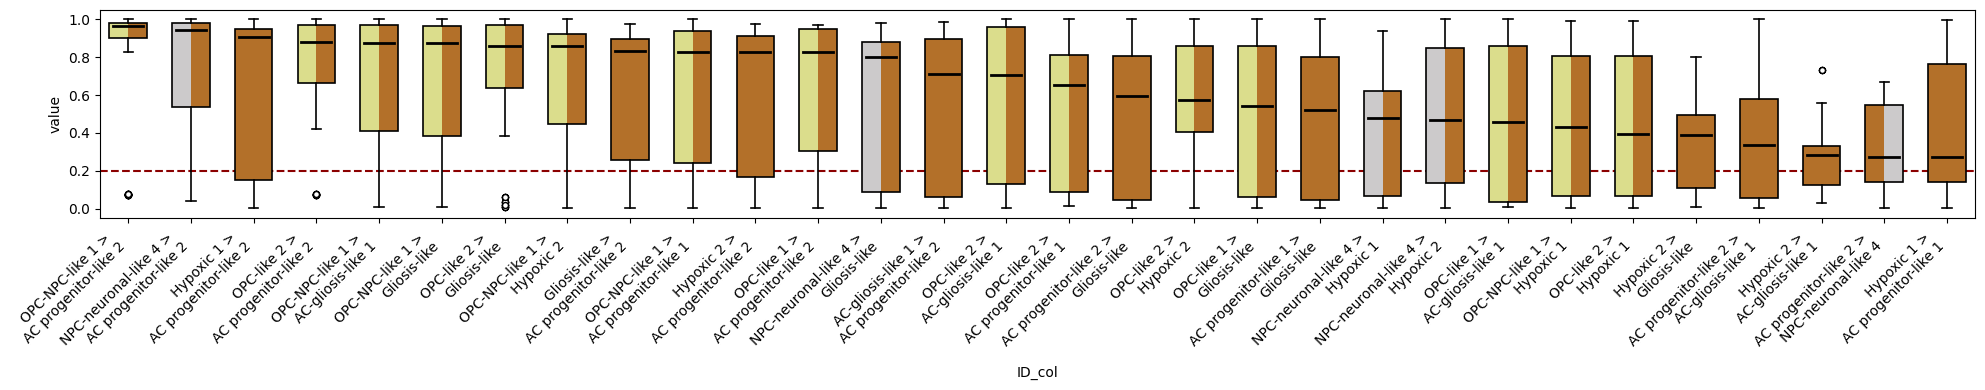

In [ ]:
fig, ax = plt.subplots(figsize=(20, 4))

categories = order
positions = np.arange(1, len(categories) + 1)
box_width = 0.6

plot_out = []
for x, cat in zip(positions, categories):
    sub = df[df["ID_col"] == cat]
    plot_out.append(sub)
    vals = sub["value"].dropna().to_numpy()

    if len(vals) == 0:
        continue

    classA_label = sub["classA"].mode().iat[0]
    classB_label = sub["classB"].mode().iat[0]

    left_color = palette[classA_label]
    right_color = palette[classB_label]

    stats = boxplot_stats(vals, whis=1.5)[0]

    q1 = stats["q1"]
    q3 = stats["q3"]
    med = stats["med"]
    whislo = stats["whislo"]
    whishi = stats["whishi"]
    fliers = stats["fliers"]

    x0 = x - box_width / 2
    xm = x
    x1 = x + box_width / 2

    # left half fill from classA
    ax.add_patch(Rectangle(
        (x0, q1),
        box_width / 2,
        q3 - q1,
        facecolor=left_color,
        edgecolor="none",
        zorder=2
    ))

    # right half fill from classB
    ax.add_patch(Rectangle(
        (xm, q1),
        box_width / 2,
        q3 - q1,
        facecolor=right_color,
        edgecolor="none",
        zorder=2
    ))

    # box outline
    ax.add_patch(Rectangle(
        (x0, q1),
        box_width,
        q3 - q1,
        facecolor="none",
        edgecolor="black",
        linewidth=1.2,
        zorder=3
    ))

    # median
    pad = box_width * 0.1   # small inset

    ax.add_line(Line2D(
        [x0 + pad, x1 - pad],
        [med, med],
        color="black",
        linewidth=2,
        zorder=4
    ))
    
    # whiskers
    ax.add_line(Line2D([x, x], [q3, whishi], color="black", linewidth=1.2, zorder=3))
    ax.add_line(Line2D([x, x], [q1, whislo], color="black", linewidth=1.2, zorder=3))

    # caps
    capw = box_width * 0.25
    ax.add_line(Line2D([x - capw/2, x + capw/2], [whishi, whishi], color="black", linewidth=1.2, zorder=3))
    ax.add_line(Line2D([x - capw/2, x + capw/2], [whislo, whislo], color="black", linewidth=1.2, zorder=3))

    # outliers
    if len(fliers):
        ax.scatter(
            np.full(len(fliers), x),
            fliers,
            s=18,
            facecolor="white",
            edgecolor="black",
            zorder=4
        )

ax.set_xticks(positions)
ax.set_xlabel("ID_col")
ax.set_ylabel("value")
ax.margins(x=0.005)

labels = [re.sub(r'>\s*', '> \n', str(c)) for c in categories]
ax.set_xticklabels(labels, rotation=45, ha="right")

plt.axhline(0.2, linestyle = '--', color = 'darkred', zorder = -1)

plt.tight_layout()
plt.savefig(outdir+'granular_transitions.pdf')

In [ ]:
plot_out = pd.concat(plot_out)
plot_out.set_index('index').to_csv('../../../data/EDFig6/EDFig6e.csv')